# Código Original

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [3]:
#load data
cancer = load_breast_cancer()

In [4]:
#check data
print("cancer.keys(): \n{}".format(cancer.keys()))
print("Shape of cancer data: {}".format(cancer.data.shape))
print("Sample counts per class:\n{}".format(
	{n: v for n, v in zip(cancer.target_names, np.bincount(cancer.target))}))
print("Feature names:\n{}".format(cancer.feature_names))

cancer.keys(): 
dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
Shape of cancer data: (569, 30)
Sample counts per class:
{np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}
Feature names:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [5]:
#split data
X_train, X_test, y_train, y_test = train_test_split(
	cancer.data, cancer.target, stratify=cancer.target, random_state=66)

In [6]:
#build model
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [7]:
#use model
pred_knn = knn.predict(X_test)

# Exercícios C

## 2.

Calcule o desempenho (exatidão) do KNN sobre os conjuntos de treino e teste com o nº de vizinhos
a variar entre 1 e 10.

In [8]:
neighbors = range(1, 11, 1)
exatidao_treino = []
exatidao_teste = []

for n in neighbors:    
    knn = KNeighborsClassifier(n_neighbors=n)
    knn.fit(X_train, y_train)
    exatidao_treino.append(knn.score(X_train, y_train))
    exatidao_teste.append(knn.score(X_test, y_test))

#tabela com resultados
df = pd.DataFrame({
    "n_vizinhos": list(neighbors),
    "exatidao_treino": exatidao_treino,
    "exatidao_teste": exatidao_teste
})

print(df.to_string(index=False))

 n_vizinhos  exatidao_treino  exatidao_teste
          1         1.000000        0.902098
          2         0.976526        0.888112
          3         0.957746        0.923077
          4         0.955399        0.923077
          5         0.948357        0.923077
          6         0.946009        0.937063
          7         0.943662        0.930070
          8         0.941315        0.930070
          9         0.934272        0.916084
         10         0.938967        0.916084


## 3.

Utilizando a biblioteca "matplotlib" faça um gráfico do desempenho (exatidão) sobre os dois
conjuntos em função do nº de vizinhos.

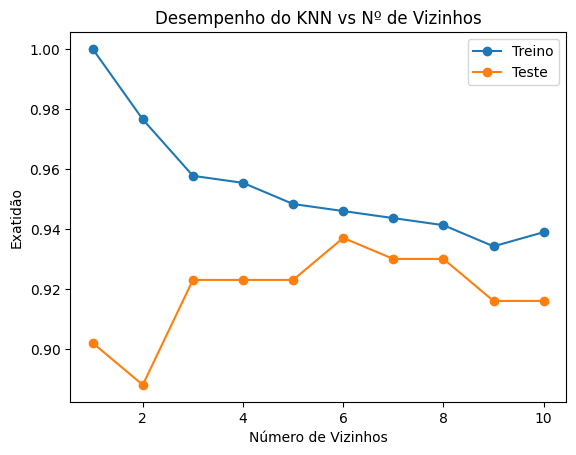

In [9]:
neighbors = range(1, 11, 1)
exatidao_treino = []
exatidao_teste = []

for n in neighbors:    
    knn = KNeighborsClassifier(n_neighbors=n)
    knn.fit(X_train, y_train)
    exatidao_treino.append(knn.score(X_train, y_train))
    exatidao_teste.append(knn.score(X_test, y_test))

plt.plot(neighbors, exatidao_treino, marker='o', label="Treino")
plt.plot(neighbors, exatidao_teste, marker='o', label="Teste")

plt.xlabel("Número de Vizinhos")
plt.ylabel("Exatidão")
plt.title("Desempenho do KNN vs Nº de Vizinhos")
plt.legend()
plt.show()